In [2]:
import json
import numpy as np
import pandas as pd
import os
from sklearn.preprocessing import MinMaxScaler

# Path to Bob's folder
bob_folder = "C:\\Users\\PC\\Desktop\\ZEYNEP\\Grad_Project_Data_Collection\\normal_traffic_data\\"

# List all JSON files in the folder
json_files = [f for f in os.listdir(bob_folder) if f.endswith(".json")]

# Initialize an empty list to store all packets
all_packets = []

# Loop through each JSON file
for file in json_files:
    with open(os.path.join(bob_folder, file), "r") as f:
        data = json.load(f)
        all_packets.extend(data["packets"])  # Append packet list

# Convert JSON data to a Pandas DataFrame
df = pd.DataFrame(all_packets)

# Select relevant columns
df = df[["hour", "minute", "second", "size", "source_port", "destination_port", "ttl", "protocol", "tcp_flags"]]

# **Dynamically One-Hot Encode Protocols**
df = pd.get_dummies(df, columns=["protocol"], prefix="protocol")

# Convert TCP flags (SYN, ACK, FIN) to numeric values
df["tcp_flags"] = df["tcp_flags"].astype(str)
df["SYN"] = df["tcp_flags"].apply(lambda x: int("SYN=true" in x))
df["ACK"] = df["tcp_flags"].apply(lambda x: int("ACK=true" in x))
df["FIN"] = df["tcp_flags"].apply(lambda x: int("FIN=true" in x))

# Drop unnecessary columns
df.drop(columns=["tcp_flags"], inplace=True)

#filled ttl column with median value
df['ttl'].fillna((df['ttl'].median()), inplace=True)

# Normalize data
scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df)

# Check if NaN values still exist
if np.isnan(df_scaled).any():
    print("Warning: NaN values exist after scaling!")

    
print("Scaled Data Shape:", df_scaled.shape)
print("Scaled Data Sample:")
print(df_scaled[:5])


# Convert to LSTM input format (Create sequences)
def create_sequences(data, sequence_length=50):
    sequences = []
    for i in range(len(data) - sequence_length):
        sequences.append(data[i : i + sequence_length])
    return np.array(sequences)

sequence_length = 50  # Use 50 packets per sequence
lstm_input = create_sequences(df_scaled, sequence_length)

# Print final shape
print("LSTM Input Shape:", lstm_input.shape)  # (num_sequences, sequence_length, num_features)


Scaled Data Shape: (33064, 12)
Scaled Data Sample:
[[0.         0.         0.28813559 0.00706941 0.9030076  0.00603687
  0.00378458 1.         0.         0.         1.         0.        ]
 [0.         0.         0.28813559 0.01413882 0.00603687 0.9030076
  0.24996566 1.         0.         0.         1.         0.        ]
 [0.         0.         0.27118644 0.00771208 0.90875037 0.43559897
  1.         0.         1.         1.         0.         0.        ]
 [0.         0.         0.27118644 0.         0.43559897 0.90875037
  0.00379984 1.         0.         0.         1.         0.        ]
 [0.         0.         0.28813559 0.00771208 0.90878133 0.90876585
  1.         0.         1.         1.         0.         0.        ]]
LSTM Input Shape: (33014, 50, 12)


C:\Users\PC\AppData\Local\Temp\ipykernel_15168\3713149013.py:41: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['ttl'].fillna((df['ttl'].median()), inplace=True)


In [18]:
# Convert the scaled data back to a DataFrame
df_scaled_df = pd.DataFrame(df_scaled, columns=df.columns)

# Save the DataFrame to a CSV file
df_scaled_df.to_csv("C:/Users/PC/Desktop/21subat/25_subat/bob_data.csv", index=False)

**CNN + LSTM hybrid with Bidirectional LSTM**

In [30]:
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Bidirectional, Dropout, RepeatVector, TimeDistributed, Dense
from tensorflow.keras.models import Model
from tensorflow.keras import Input

# Define the input shape
timesteps = sequence_length  # Adjust based on your data
n_features = lstm_input.shape[2]  # Adjust based on your scaled data features

# Input layer
input_layer = Input(shape=(timesteps, n_features))

# CNN for feature extraction
conv = Conv1D(filters=64, kernel_size=3, activation="relu", padding="same")(input_layer)
conv = MaxPooling1D(pool_size=2, padding="same")(conv)

# Encoder with Bidirectional LSTM
encoded = Bidirectional(LSTM(64, activation="relu", return_sequences=True))(conv)
encoded = Bidirectional(LSTM(32, activation="relu", return_sequences=False))(encoded)  # Latent space

# Decoder with LSTM layers
decoded = RepeatVector(timesteps)(encoded)
decoded = LSTM(32, activation="relu", return_sequences=True)(decoded)
decoded = LSTM(64, activation="relu", return_sequences=True)(decoded)
decoded = TimeDistributed(Dense(n_features))(decoded)

# Autoencoder model
autoencoder = Model(inputs=input_layer, outputs=decoded)
autoencoder.compile(optimizer="adam", loss="mse")
autoencoder.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 50, 12)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 50, 64)         │         2,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 25, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ (None, 25, 128)        │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_2 (RepeatVector)  │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_10 (LSTM)                  │ (None, 50, 32)         │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 50, 64)         │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 50, 12)         │           780 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 147,660 (576.80 KB)

 Trainable params: 147,660 (576.80 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
X_train = lstm_input.reshape((lstm_input.shape[0] ,  lstm_input.shape[1], lstm_input.shape[2]))
print(X_train.shape)

(33014, 50, 12)


In [32]:
# Train the model
history = autoencoder.fit(X_train, X_train, epochs=50, batch_size=64, validation_split=0.2, shuffle=True)


Epoch 1/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 22s 40ms/step - loss: 0.0798 - val_loss: 0.0347
Epoch 2/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 15s 36ms/step - loss: 0.0382 - val_loss: 0.0301
Epoch 3/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 17s 42ms/step - loss: 0.0335 - val_loss: 0.0270
Epoch 4/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 21s 50ms/step - loss: 0.0307 - val_loss: 0.0267
Epoch 5/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 21s 50ms/step - loss: 0.0293 - val_loss: 0.0254
Epoch 6/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 22s 54ms/step - loss: 0.0288 - val_loss: 0.0248
Epoch 7/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 22s 52ms/step - loss: 0.0280 - val_loss: 0.0250
Epoch 8/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 21s 50ms/step - loss: 0.0276 - val_loss: 0.0244
Epoch 9/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 20s 49ms/step - loss: 0.0273 - val_loss: 0.0244
Epoch 10/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 24s 57ms/step - loss: 0.0269 - val_loss: 0.0246
Epoch 11/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 17s 40ms/step - loss: 0.0267 - val_loss: 0.0244
Epoch 12/50
413/413 ━━━━━━━━━━

In [33]:
#model save
autoencoder.save("C:/Users/PC/Desktop/21subat/25_subat/CNN_LSTM_Bidirectional_model.h5")

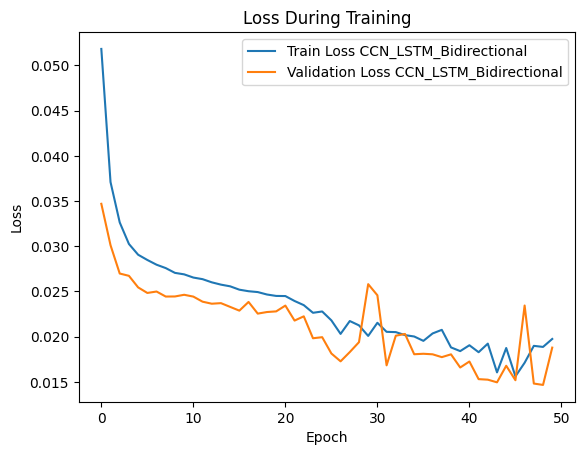

In [45]:
import matplotlib.pyplot as plt

# Plot the loss for training and validation sets
plt.plot(history.history['loss'], label='Train Loss CCN_LSTM_Bidirectional')
plt.plot(history.history['val_loss'], label='Validation Loss CCN_LSTM_Bidirectional')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss During Training')
plt.legend()
plt.show()


**LSTM AUTOENCODER MODEL**

In [37]:
from tensorflow.keras.layers import LSTM, RepeatVector, TimeDistributed
from tensorflow.keras.models import Sequential

# Define the LSTM Autoencoder model
lstm_autoencoder = Sequential([
    LSTM(64, activation="relu", input_shape=(timesteps, n_features), return_sequences=True),
    LSTM(32, activation="relu", return_sequences=False),  # Latent space
    RepeatVector(timesteps),  # Expand back to original sequence length
    LSTM(32, activation="relu", return_sequences=True),
    LSTM(64, activation="relu", return_sequences=True),
    TimeDistributed(Dense(n_features))  # Output layer
])

# Compile the model
lstm_autoencoder.compile(optimizer="adam", loss="mse")
lstm_autoencoder.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_20 (LSTM)                  │ (None, 50, 64)         │        19,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_21 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_5 (RepeatVector)  │ (None, 50, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_22 (LSTM)                  │ (None, 50, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_23 (LSTM)                  │ (None, 50, 64)         │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_5              │ (None, 50, 12)         │           780 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66,060 (258.05 KB)

 Trainable params: 66,060 (258.05 KB)

 Non-trainable params: 0 (0.00 B)

In [38]:
history_lstm = lstm_autoencoder.fit(X_train, X_train, epochs=50, batch_size=64, validation_split=0.2, shuffle=True)


Epoch 1/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 20s 38ms/step - loss: 0.1036 - val_loss: 0.0359
Epoch 2/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 16s 39ms/step - loss: 0.0398 - val_loss: 0.0333
Epoch 3/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 18s 43ms/step - loss: 0.0370 - val_loss: 0.0297
Epoch 4/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 20s 48ms/step - loss: 0.0324 - val_loss: 0.0274
Epoch 5/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 19s 47ms/step - loss: 0.0312 - val_loss: 0.0271
Epoch 6/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 18s 43ms/step - loss: 0.0302 - val_loss: 0.0265
Epoch 7/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 17s 41ms/step - loss: 0.0294 - val_loss: 0.0265
Epoch 8/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 18s 43ms/step - loss: 0.0292 - val_loss: 0.0257
Epoch 9/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 18s 44ms/step - loss: 0.0287 - val_loss: 0.0257
Epoch 10/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 18s 44ms/step - loss: 0.0282 - val_loss: 0.0255
Epoch 11/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 18s 44ms/step - loss: 0.0278 - val_loss: 0.0249
Epoch 12/50
413/413 ━━━━━━━━━━

In [39]:
lstm_autoencoder.save("C:/Users/PC/Desktop/21subat/25_subat/just_lstm_autoencoder.h5")


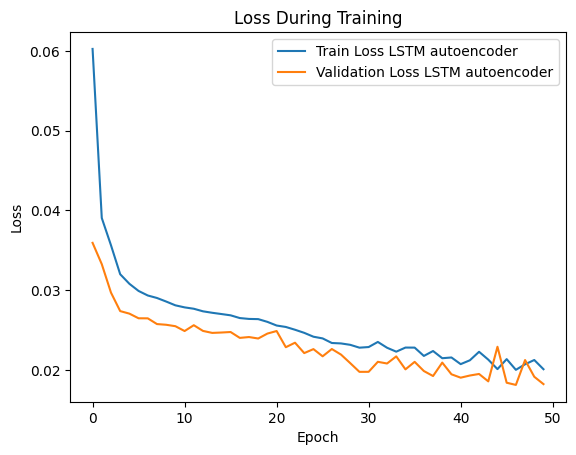

In [46]:
import matplotlib.pyplot as plt

# Plot the loss for training and validation sets
plt.plot(history_lstm.history['loss'], label='Train Loss LSTM autoencoder')
plt.plot(history_lstm.history['val_loss'], label='Validation Loss LSTM autoencoder' )
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss During Training')
plt.legend()
plt.show()

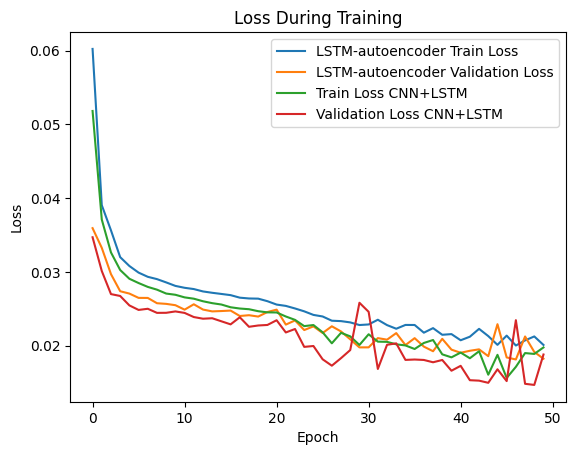

In [44]:
import matplotlib.pyplot as plt

# Plot the loss for training and validation sets
plt.plot(history_lstm.history['loss'], label='LSTM-autoencoder Train Loss')
plt.plot(history_lstm.history['val_loss'], label='LSTM-autoencoder Validation Loss')
plt.plot(history.history['loss'], label='Train Loss CNN+LSTM')
plt.plot(history.history['val_loss'], label='Validation Loss CNN+LSTM')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss During Training')
plt.legend()
plt.show()

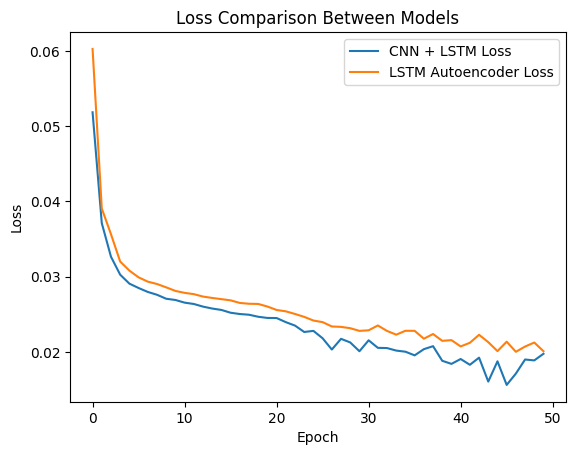

In [40]:
plt.plot(history.history['loss'], label='CNN + LSTM Loss')
plt.plot(history_lstm.history['loss'], label='LSTM Autoencoder Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Comparison Between Models')
plt.legend()
plt.show()
